## Apply Filters to Different Waveforms

This example uses bias T connected between I1 and O1 of the QRM.\
Run generateIIR.ipynb first to generate some filter data.

In [1]:
fileName = "1MOhmFilterData.json"

In [2]:
#sys.path is used to access predistort.py in parent directory
import sys, os
sys.path.append(os.path.dirname(os.path.abspath("")))
import predistort

import json
import matplotlib.pyplot as plt
from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType
import scipy.optimize
import numpy as np

print(predistort.__doc__)


predistort.py

Handles the generation and testing of infinite impulse reponse (IIR) filters
which are used to correct for the signal distortion caused by an electical system.
To preform the correction, a square pulse is sent through the system and the response is
measured. An exponential decay function is then fit to the response, to extract function parameters.
By taking the reciprocal of the Laplace transform of the decay function, we get the inverse transfer function.
The bilinear transform of the transfer function is taken next to determine filter coefficients a1, b0, b1,
of the IIR filter. This approach is then iterated on until the output of the system procduces the ideal signal
of a flat square pulse. The filter coefficents can then be applied to an arbitrary pulse to correct for distortions.

The correction approach is based on the following work:
J. Butscher, "Shaping of Fast Flux Pulses for Two-Qubit Gates: Inverse Filtering", M.S. thesis,
	Quantum Device Lab, ETH Zurich, Zu

#### Connect and Configure Qblox Cluster

In [3]:
#Scan for clusters
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


In [4]:
acquisitionAvgCount = 100

"""
This is a temporary file, it is deleted after upload
to the sequencer. Unique file name was chosen to ensure
no naming conflicts with other files in the directory
"""
jsonSequenceFileName = "applyIIRExampleSequence.json"

#Using a QRM
cluster = Cluster("cluster_mm", "192.168.137.2")
module = None

modules = [mod for mod in cluster.modules if mod.present()]
for mod in modules:
	if mod.module_type == InstrumentType.QRM:
		module = mod
if module == None:
	print("Error: Module of type " + str(InstrumentType.QRM) + " not found.")
	quit()

cluster.reset()
cluster.get_system_state()

#Configure sequencers for this experiment
module.scope_acq_avg_mode_en_path0(True)
module.scope_acq_sequencer_select(0)
module.scope_acq_trigger_mode_path0("sequencer")
module.scope_acq_trigger_mode_path1("sequencer")
module.disconnect_inputs()
module.disconnect_outputs()
module.sequencer0.connect_sequencer("io0_1")

def generateSequenceJson(waveform:list[float]):
	waveforms = {"block": {"data": waveform, "index": 0,},}
	acquisitions = {"response": {"num_bins": 1,"index": 0}}	
	seq_prog = f"""
			move    {acquisitionAvgCount},R0   #Loop iterator.

			loop: 	play    0,0,4     #Play waveforms and wait 4ns.
					acquire 0,0,16384
					wait	24000
					loop    R0,@loop  #Run until number of iterations is done.

					stop              #Stop.
			"""
	
	sequence = {"waveforms": waveforms,"weights": {},"acquisitions": acquisitions,"program": seq_prog,}

	#Check that file doesnt exist
	path = os.path.dirname(os.path.realpath(""))
	if (os.path.exists(path + f"/{jsonSequenceFileName}")):
		print(f"Error: The file {jsonSequenceFileName} already exists in current directory!")
		quit()

	with open(jsonSequenceFileName, "w", encoding="utf-8") as file:
		json.dump(sequence, file, indent=4)
		file.close()

def playPulse(waveform:list[float]) -> list[float]:
	generateSequenceJson(waveform)
	module.sequencer0.sequence(jsonSequenceFileName)
	os.remove(jsonSequenceFileName)

	module.arm_sequencer(0)
	module.start_sequencer()
	module.get_sequencer_state(0, timeout=1)
	module.get_acquisition_state(0, 1)
	module.store_scope_acquisition(0, "response")
	acqData = module.get_acquisitions(0)
	module.delete_acquisition_data(0, all=True)
	return acqData["response"]["acquisition"]["scope"]["path0"]["data"]

#### Load Filter Data

In [5]:
iterationData = None
with open(fileName, encoding="utf-8") as file:
	iterationData = json.load(file)
	file.close()

#### Test Filters on Different Waveforms and Plot Results

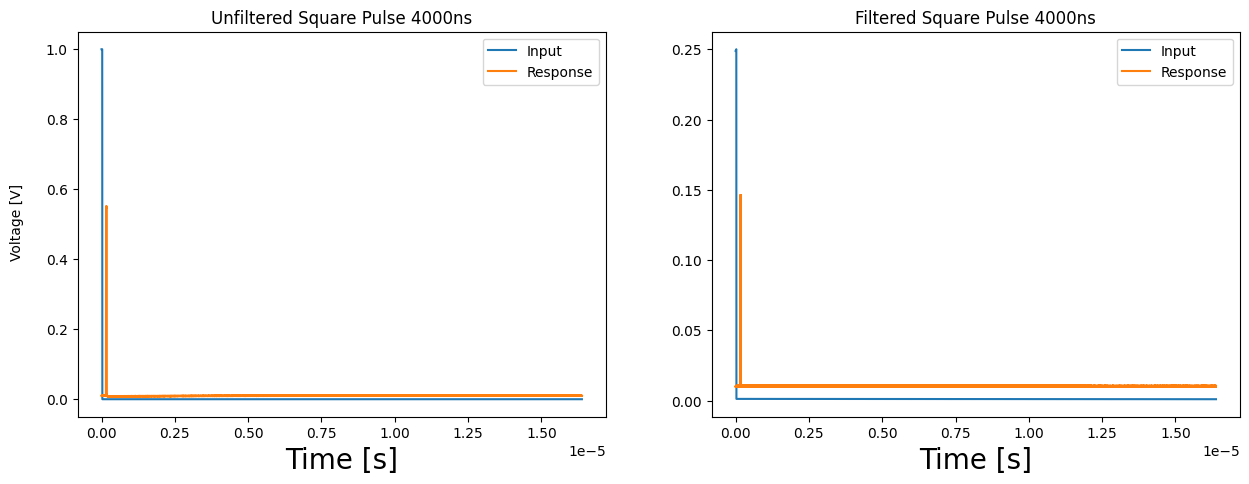

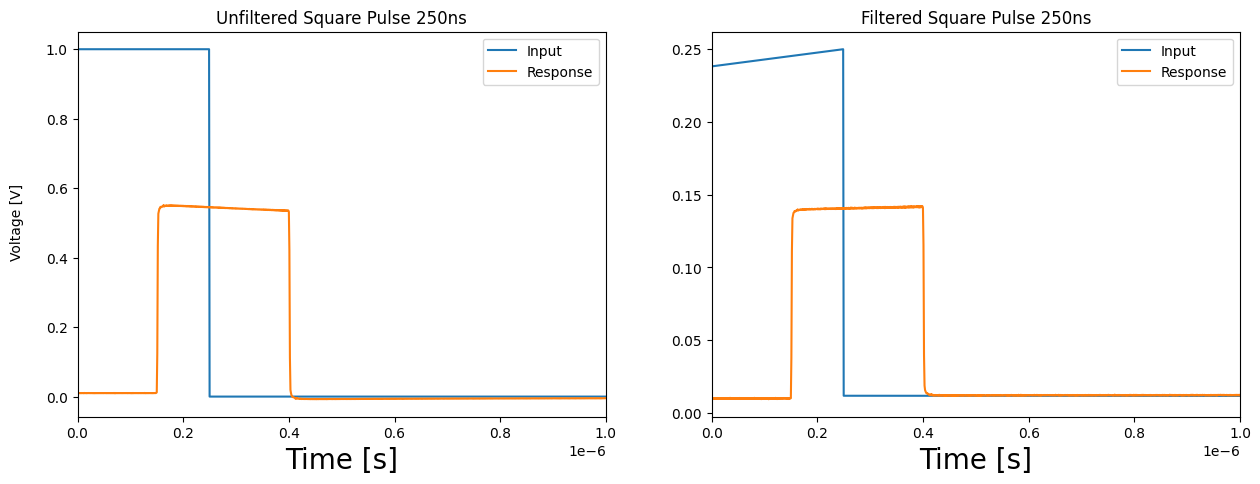

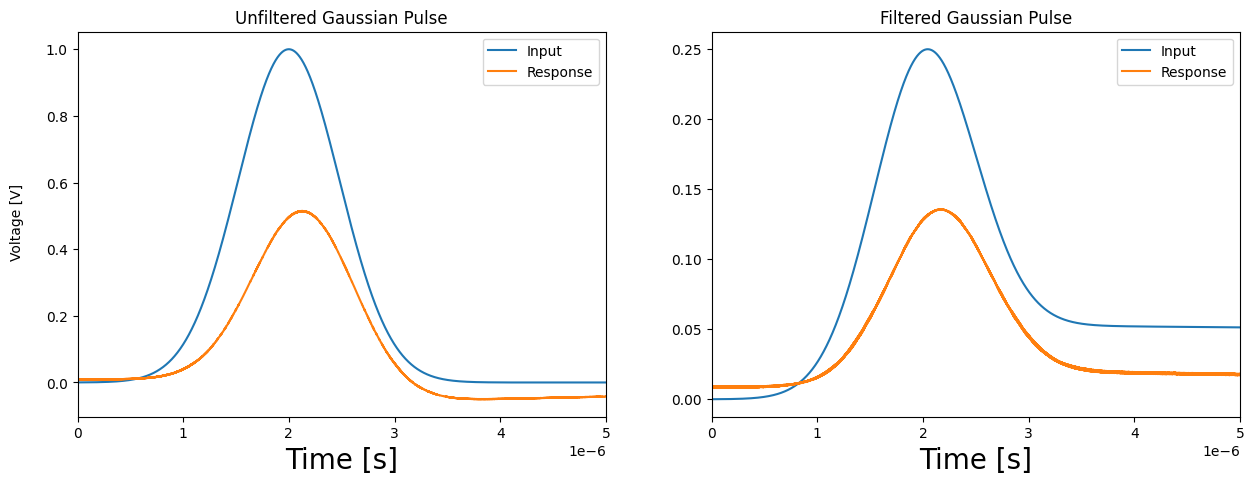

In [6]:
#Test filters on some waveforms
samplePeriodAwg = 1e-9
acqMaxTime = 16384	#Waveform acquisition, defined by Qblox
xData = [i*samplePeriodAwg for i in range(acqMaxTime)] #Convert from samples to time

def plotData(unfilteredInput, filteredInput, title, show=True):
	fig, ax = plt.subplots(1, 2, sharex=True, figsize = (15, 5))
	ax[0].plot(xData, unfilteredInput, label="Input")
	ax[0].plot(xData, playPulse(unfilteredInput), label="Response")
	ax[0].set_xlabel("Time [s]", fontsize=20)
	ax[0].set_title("Unfiltered " + title)
	ax[0].legend(loc="upper right")
	ax[1].plot(xData, filteredInput, label="Input")
	ax[1].plot(xData, playPulse(filteredInput), label="Response")
	ax[1].set_xlabel("Time [s]", fontsize=20)
	ax[1].set_title("Filtered " + title)
	ax[1].legend(loc="upper right")

	fig.text(0.08, 0.5, 'Voltage [V]', va='center', rotation='vertical')
	if show:
		plt.show()
	return fig, ax

pulseDuration = 25
squarePulse = [1.0 for i in range(pulseDuration)] + [0.0 for i in range(acqMaxTime - pulseDuration)]
filteredPulse = predistort.applyFiltersToWaveform(iterationData, squarePulse)
plotData(squarePulse, filteredPulse, "Square Pulse 4000ns")

pulseDuration = 250
squarePulse = [1.0 for i in range(pulseDuration)] + [0.0 for i in range(acqMaxTime - pulseDuration)]
filteredPulse = predistort.applyFiltersToWaveform(iterationData, squarePulse)
fig, ax = plotData(squarePulse, filteredPulse, "Square Pulse 250ns", show=False)
ax[0].set_xlim(0, 1000*samplePeriodAwg)
plt.show()

pulseDuration = 4000
gaussianPulse = scipy.signal.windows.gaussian(pulseDuration, std=0.12*pulseDuration).tolist() + [0.0 for i in range(acqMaxTime - pulseDuration)]
filteredPulse = predistort.applyFiltersToWaveform(iterationData, gaussianPulse)
fig, ax = plotData(gaussianPulse, filteredPulse, "Gaussian Pulse", show=False)
ax[0].set_xlim(0, 5000*samplePeriodAwg)
plt.show()